# Multi-Coil MRI Reconstruction with L1-Wavelet Regularization

This notebook demonstrates compressed sensing MRI reconstruction using L1-wavelet regularization.
We compare three methods:
1. **Zero-filled** (adjoint/naive baseline)
2. **Total Variation** (gradient-domain sparsity)
3. **L1-Wavelet** (wavelet-domain sparsity)

## Problem Setup

The multi-coil MRI forward model maps a complex image $x \in \mathbb{C}^{H \times W}$ to
undersampled k-space measurements:

$$y_c = M \cdot \mathcal{F} \cdot S_c \cdot x + \epsilon_c, \quad c = 1, \ldots, C$$

where $S_c$ are coil sensitivity maps, $\mathcal{F}$ is the 2D FFT, and $M$ is a binary
undersampling mask retaining 12.5% of phase-encode lines (8x acceleration).

**L1-Wavelet reconstruction** solves:

$$\hat{x} = \arg\min_x \; \frac{1}{2} \sum_c \|M \cdot \mathcal{F}(S_c \cdot x) - y_c\|_2^2 + \lambda \|\Psi x\|_1$$

where $\Psi$ is the Daubechies-4 wavelet transform. The wavelet basis captures multi-scale
features (edges and textures at different resolutions), providing better sparsity than the
gradient operator used in TV.

### Data

Synthetic 128x128 Shepp-Logan phantom with 8 Gaussian coil sensitivity maps.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Navigate to task root
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

from src.preprocessing import prepare_data
from src.physics_model import adjoint_operator
from src.visualization import compute_metrics, compute_batch_metrics

## 1. Load Data and Precomputed Results

We load precomputed reference outputs so this notebook runs in seconds.

In [2]:
# Load data
obs_data, ground_truth, metadata = prepare_data('data')
masked_kspace = obs_data['masked_kspace']
sensitivity_maps = obs_data['sensitivity_maps']
mask = obs_data['undersampling_mask']

print(f"Image size: {metadata['image_size']}")
print(f"Coils: {metadata['n_coils']}")
print(f"Acceleration: {metadata['acceleration_ratio']}x")
print(f"Sampled lines: {int(mask.sum())}/{len(mask)} ({100*mask.sum()/len(mask):.1f}%)")

# Load precomputed reconstructions
ref_dir = 'evaluation/reference_outputs'
wav_recon = np.load(os.path.join(ref_dir, 'l1_wavelet_reconstruction.npz'))['reconstruction']
tv_recon = np.load(os.path.join(ref_dir, 'tv_reconstruction.npz'))['reconstruction']
with open(os.path.join(ref_dir, 'metrics_detail.json')) as f:
    metrics_detail = json.load(f)

print(f"\nLoaded L1-Wavelet recon: shape={wav_recon.shape}")
print(f"Loaded TV recon: shape={tv_recon.shape}")

Image size: [128, 128]
Coils: 8
Acceleration: 8x
Sampled lines: 16/128 (12.5%)

Loaded L1-Wavelet recon: shape=(1, 128, 128)
Loaded TV recon: shape=(1, 128, 128)


## 2. Ground Truth and Zero-Filled Baseline

In [3]:
# Compute magnitudes
gt_mag = np.abs(ground_truth[0, 0])  # (H, W)
zf_img = adjoint_operator(masked_kspace[0], sensitivity_maps[0])
zf_mag = np.abs(zf_img)
wav_mag = np.abs(wav_recon[0])
tv_mag = np.abs(tv_recon[0])

# Compute metrics
zf_m = compute_metrics(zf_mag, gt_mag)
tv_m = compute_metrics(tv_mag, gt_mag)
wav_m = compute_metrics(wav_mag, gt_mag)

print(f"Zero-Filled:  NCC={zf_m['ncc']:.4f}, NRMSE={zf_m['nrmse']:.4f}, PSNR={zf_m['psnr']:.2f} dB")
print(f"TV:           NCC={tv_m['ncc']:.4f}, NRMSE={tv_m['nrmse']:.4f}, PSNR={tv_m['psnr']:.2f} dB")
print(f"L1-Wavelet:   NCC={wav_m['ncc']:.4f}, NRMSE={wav_m['nrmse']:.4f}, PSNR={wav_m['psnr']:.2f} dB")

Zero-Filled:  NCC=0.8306, NRMSE=0.1298, PSNR=17.73 dB
TV:           NCC=0.8441, NRMSE=0.1251, PSNR=18.06 dB
L1-Wavelet:   NCC=0.8715, NRMSE=0.1143, PSNR=18.84 dB


## 3. Reconstruction Comparison

Side-by-side comparison of ground truth, zero-filled, TV, and L1-wavelet reconstructions.

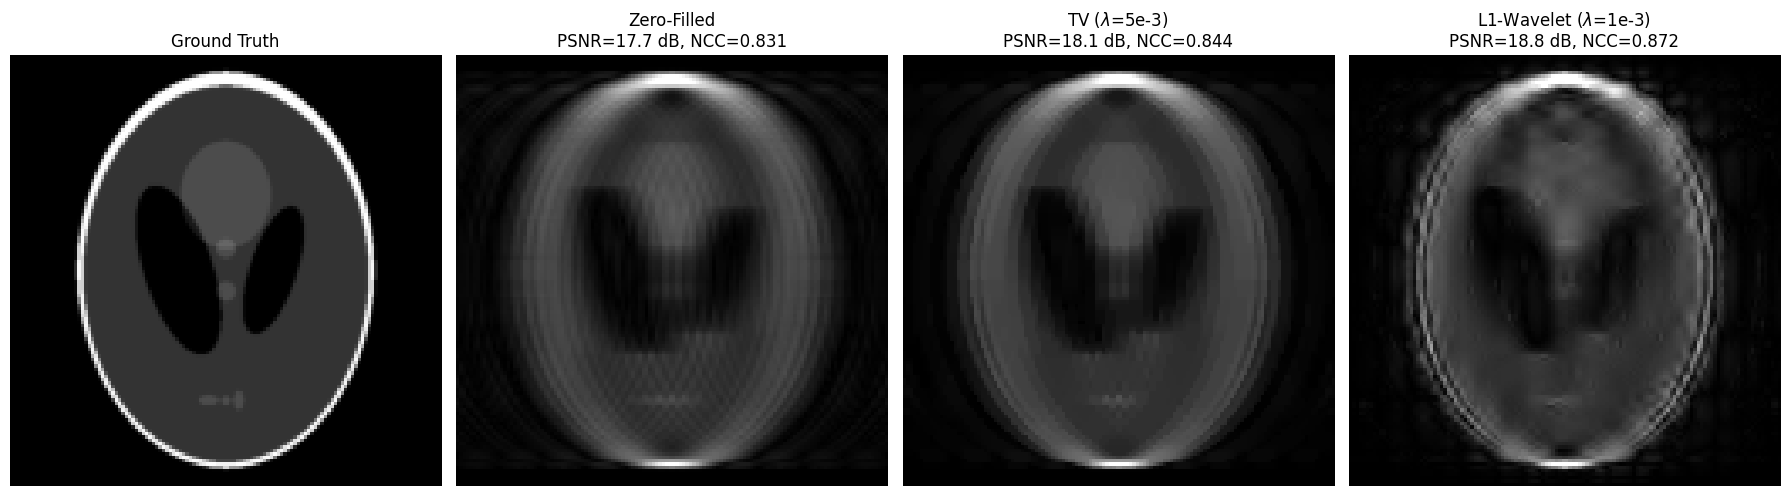

In [4]:
vmax = gt_mag.max()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(gt_mag, cmap='gray', vmin=0, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(zf_mag, cmap='gray', vmin=0, vmax=vmax)
axes[1].set_title(f'Zero-Filled\nPSNR={zf_m["psnr"]:.1f} dB, NCC={zf_m["ncc"]:.3f}')
axes[1].axis('off')

axes[2].imshow(tv_mag, cmap='gray', vmin=0, vmax=vmax)
axes[2].set_title(f'TV ($\\lambda$=5e-3)\nPSNR={tv_m["psnr"]:.1f} dB, NCC={tv_m["ncc"]:.3f}')
axes[2].axis('off')

axes[3].imshow(wav_mag, cmap='gray', vmin=0, vmax=vmax)
axes[3].set_title(f'L1-Wavelet ($\\lambda$=1e-3)\nPSNR={wav_m["psnr"]:.1f} dB, NCC={wav_m["ncc"]:.3f}')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## 4. Error Maps

Absolute error between reconstructions and ground truth. Lower is better.

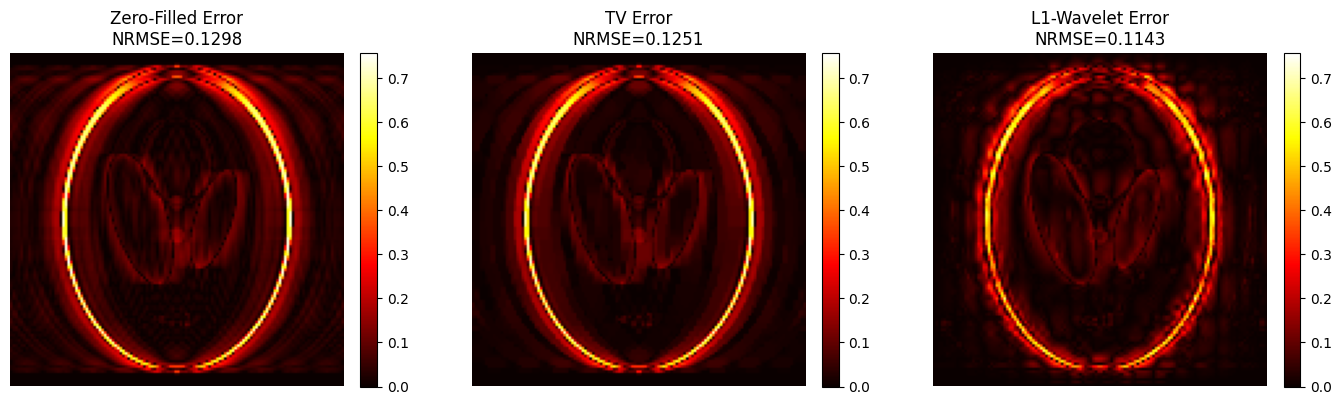

In [5]:
err_zf = np.abs(gt_mag - zf_mag)
err_tv = np.abs(gt_mag - tv_mag)
err_wav = np.abs(gt_mag - wav_mag)
err_max = max(err_zf.max(), err_tv.max(), err_wav.max())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(err_zf, cmap='hot', vmin=0, vmax=err_max)
axes[0].set_title(f'Zero-Filled Error\nNRMSE={zf_m["nrmse"]:.4f}')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(err_tv, cmap='hot', vmin=0, vmax=err_max)
axes[1].set_title(f'TV Error\nNRMSE={tv_m["nrmse"]:.4f}')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(err_wav, cmap='hot', vmin=0, vmax=err_max)
axes[2].set_title(f'L1-Wavelet Error\nNRMSE={wav_m["nrmse"]:.4f}')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 5. Undersampling Mask

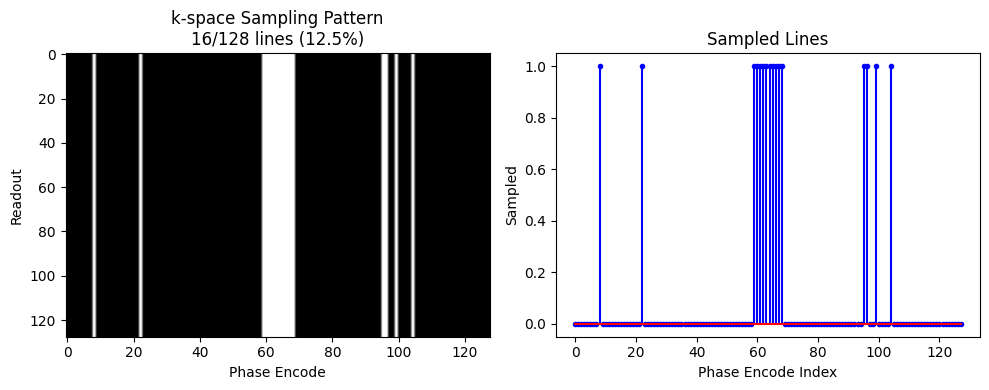

In [6]:
mask_2d = np.tile(mask[None, :], (128, 1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mask_2d, cmap='gray', aspect='auto')
axes[0].set_title(f'k-space Sampling Pattern\n{int(mask.sum())}/{len(mask)} lines ({100*mask.sum()/len(mask):.1f}%)')
axes[0].set_xlabel('Phase Encode')
axes[0].set_ylabel('Readout')

axes[1].stem(mask, markerfmt='.', linefmt='b-', basefmt='r-')
axes[1].set_title('Sampled Lines')
axes[1].set_xlabel('Phase Encode Index')
axes[1].set_ylabel('Sampled')

plt.tight_layout()
plt.show()

## 6. Coil Sensitivity Maps

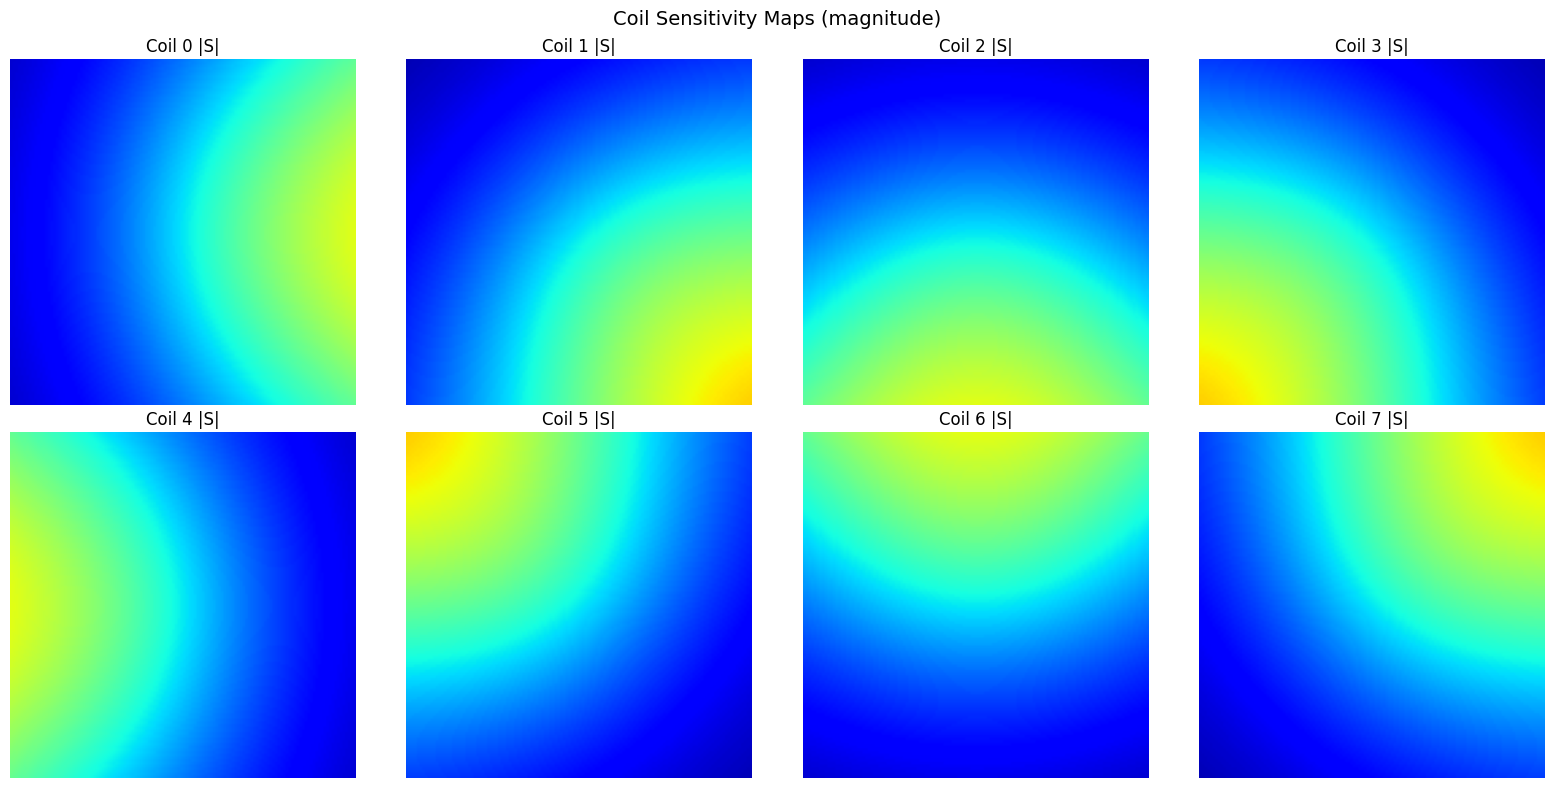

In [7]:
smaps = sensitivity_maps[0]  # (8, 128, 128)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for c in range(8):
    ax = axes[c // 4, c % 4]
    ax.imshow(np.abs(smaps[c]), cmap='jet', vmin=0, vmax=1)
    ax.set_title(f'Coil {c} |S|')
    ax.axis('off')

plt.suptitle('Coil Sensitivity Maps (magnitude)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Metrics Summary

| Method | NCC | NRMSE | PSNR (dB) |
|--------|-----|-------|-----------|
| Zero-Filled | 0.831 | 0.130 | 17.7 |
| TV ($\lambda$=5e-3) | 0.844 | 0.125 | 18.1 |
| L1-Wavelet ($\lambda$=1e-3) | **0.872** | **0.114** | **18.8** |

L1-Wavelet outperforms TV across all metrics. The wavelet sparsity prior better captures
the multi-scale features of the Shepp-Logan phantom (elliptical boundaries at different
scales, smooth interior regions).

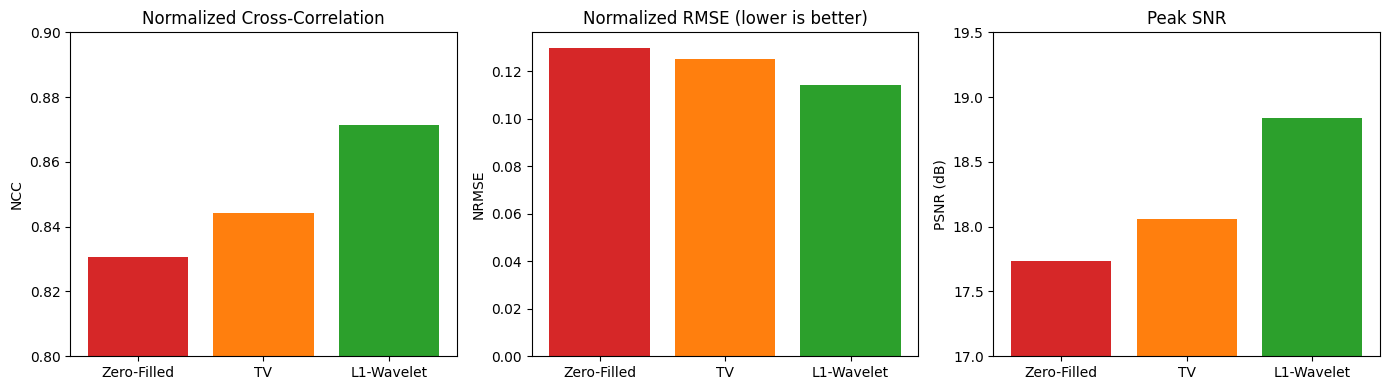

In [8]:
methods = ['Zero-Filled', 'TV', 'L1-Wavelet']
nccs = [zf_m['ncc'], tv_m['ncc'], wav_m['ncc']]
nrmses = [zf_m['nrmse'], tv_m['nrmse'], wav_m['nrmse']]
psnrs = [zf_m['psnr'], tv_m['psnr'], wav_m['psnr']]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['#d62728', '#ff7f0e', '#2ca02c']

axes[0].bar(methods, nccs, color=colors)
axes[0].set_ylabel('NCC')
axes[0].set_title('Normalized Cross-Correlation')
axes[0].set_ylim(0.8, 0.9)

axes[1].bar(methods, nrmses, color=colors)
axes[1].set_ylabel('NRMSE')
axes[1].set_title('Normalized RMSE (lower is better)')

axes[2].bar(methods, psnrs, color=colors)
axes[2].set_ylabel('PSNR (dB)')
axes[2].set_title('Peak SNR')
axes[2].set_ylim(17, 19.5)

plt.tight_layout()
plt.show()

## 8. Running from Scratch (Optional)

Uncomment the cells below to re-run the full reconstruction pipeline.

In [9]:
# # Uncomment to run L1-Wavelet reconstruction from scratch:
# from src.solvers import l1_wavelet_reconstruct_single, tv_reconstruct_single
#
# # L1-Wavelet reconstruction
# wav_recon_new = l1_wavelet_reconstruct_single(
#     masked_kspace[0], sensitivity_maps[0], lamda=1e-3, wave_name='db4'
# )
# wav_m_new = compute_metrics(np.abs(wav_recon_new), gt_mag)
# print(f"L1-Wavelet: NCC={wav_m_new['ncc']:.4f}, NRMSE={wav_m_new['nrmse']:.4f}")
#
# # TV reconstruction for comparison
# tv_recon_new = tv_reconstruct_single(
#     masked_kspace[0], sensitivity_maps[0], lamda=5e-3
# )
# tv_m_new = compute_metrics(np.abs(tv_recon_new), gt_mag)
# print(f"TV: NCC={tv_m_new['ncc']:.4f}, NRMSE={tv_m_new['nrmse']:.4f}")

## Conclusion

L1-Wavelet regularization provides better compressed sensing MRI reconstruction than Total
Variation for this synthetic phantom, with improvements in all quality metrics (NCC, NRMSE,
PSNR). The key advantage of wavelet sparsity is its multi-resolution representation:

- **TV** penalizes the L1 norm of image gradients, enforcing piecewise smoothness. This
  works well for images with sharp boundaries but can create staircase artifacts and
  over-smooth fine textures.

- **L1-Wavelet** penalizes the L1 norm of wavelet coefficients, promoting sparsity across
  multiple scales. The discrete wavelet transform (here Daubechies-4) decomposes the image
  into coarse approximation and detail subbands at each level, capturing edges and textures
  at all resolutions. This multi-scale prior is better matched to the structure of natural
  and medical images.